In [ ]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets

In [2]:
# =========================================================
# 1) Reproducibility
# =========================================================
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cpu


In [3]:
# =========================================================
# 2) Model 
# =========================================================
class AblationMLP(nn.Module):
    def __init__(self, use_dropout=False, use_batchnorm=False, dropout_p=0.2, hidden_sizes=None):
        super(AblationMLP, self).__init__()

        if hidden_sizes is None:
            hidden_sizes = [1024, 512, 256]

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3072, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0]) if use_batchnorm else None
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1]) if use_batchnorm else None
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2]) if use_batchnorm else None
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_p) if use_dropout else None

        self.fc4 = nn.Linear(hidden_sizes[2], 10)

        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu1(x)
        if self.use_dropout:
            x = self.dropout1(x)

        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu2(x)
        if self.use_dropout:
            x = self.dropout2(x)

        x = self.fc3(x)
        if self.use_batchnorm:
            x = self.bn3(x)
        x = self.relu3(x)
        if self.use_dropout:
            x = self.dropout3(x)

        x = self.fc4(x)
        return x

In [4]:
# =========================================================
# 3) Data Transforms
# =========================================================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

In [5]:
# =========================================================
# 4) Load CIFAR-10
# =========================================================
full_train_aug  = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
full_train_eval = datasets.CIFAR10(root='./data', train=True,  download=True, transform=eval_transform)
full_test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=eval_transform)

/Users/omar/Documents/uni/DL/project_1/dl_env/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
# =========================================================
# 5) Split: Train 15k | Val 5k | Test 10k
# =========================================================
generator = torch.Generator().manual_seed(42)
all_indices = torch.randperm(len(full_train_aug), generator=generator).tolist()

train_indices = all_indices[:15000]
val_indices   = all_indices[15000:20000]

train_dataset = torch.utils.data.Subset(full_train_aug,  train_indices)
val_dataset   = torch.utils.data.Subset(full_train_eval, val_indices)
test_dataset  = full_test_dataset

# clean train eval for fair train metrics
train_dataset_clean_eval = torch.utils.data.Subset(full_train_eval, train_indices)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
train_loader_clean_eval = torch.utils.data.DataLoader(train_dataset_clean_eval, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print("=" * 80)
print("DATA PARTITIONING")
print("=" * 80)
print(f"Training set size:   {len(train_dataset):,} images")
print(f"Validation set size: {len(val_dataset):,} images")
print(f"Test set size:       {len(test_dataset):,} images")
print("=" * 80)

DATA PARTITIONING
Training set size:   15,000 images
Validation set size: 5,000 images
Test set size:       10,000 images


In [7]:
# =========================================================
# 6) Fixed full-combo settings 
# =========================================================
max_epochs = 50
dropout_p = 0.2
l1_lambda = 5e-7
l2_weight_decay = 1e-4

use_adversarial_training = True
adv_ratio = 0.15
epsilon = 0.03

use_early_stopping = True
patience = 10
min_delta = 0.001

In [8]:
# =========================================================
# 7) Helper Functions
# =========================================================
def evaluate(model, dataloader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    model.train()
    return 100 * correct / total

def compute_loss(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += loss_fn(outputs, labels).item()
    model.train()
    return total_loss / len(dataloader)

def compute_l1_penalty(model):
    l1_penalty = 0.0
    for param in model.parameters():
        l1_penalty += torch.sum(torch.abs(param))
    return l1_penalty

def fgsm_attack(model, images, labels, epsilon, loss_fn):
    images_adv = images.clone().detach().requires_grad_(True)
    outputs = model(images_adv)
    loss = loss_fn(outputs, labels)
    model.zero_grad()
    loss.backward()
    adv_images = images_adv + epsilon * images_adv.grad.sign()
    adv_images = torch.clamp(adv_images, -3.0, 3.0)
    return adv_images.detach()

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_loss = float("inf")
        self.counter = 0
        self.best_state = None
        self.stop = False

    def step(self, val_loss, model):
        if val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

def train_epoch(model, train_loader, optimizer, loss_fn, device,
                l1_lambda=0.0, use_adv=False, adv_ratio=0.0, epsilon=0.03):
    model.train()
    total_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_adv and np.random.rand() < adv_ratio:
            adv_images = fgsm_attack(model, images, labels, epsilon, loss_fn)
            outputs = model(adv_images)
        else:
            outputs = model(images)

        ce_loss = loss_fn(outputs, labels)
        l1_penalty = compute_l1_penalty(model)
        loss = ce_loss + l1_lambda * l1_penalty

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

def evaluate_adversarial(model, dataloader, device, loss_fn, epsilon=0.03):
    model.eval()
    correct, total = 0, 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        adv_images = fgsm_attack(model, images, labels, epsilon, loss_fn)
        with torch.no_grad():
            outputs = model(adv_images)
            _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    model.train()
    return 100 * correct / total


In [9]:
# =========================================================
# 8) Optimization factory functions
# =========================================================
def create_optimizer(model, optimizer_name, lr, weight_decay):
    if optimizer_name == "SGD":
        return optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD+Momentum":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

def create_scheduler(optimizer, scheduler_name, max_epochs):
    if scheduler_name == "None":
        return None
    elif scheduler_name == "StepLR":
        return optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    elif scheduler_name == "CosineAnnealingLR":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-5)
    elif scheduler_name == "ReduceLROnPlateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    else:
        raise ValueError(f"Unknown scheduler: {scheduler_name}")


In [10]:
# =========================================================
# 9) Main experiment runner
# =========================================================
def run_experiment(optimizer_name="AdamW", lr=1e-3, scheduler_name="CosineAnnealingLR", verbose=False):
    model = AblationMLP(
        use_dropout=True,
        use_batchnorm=True,
        dropout_p=dropout_p,
        hidden_sizes=[1024, 512, 256]
    ).to(device)

    optimizer = create_optimizer(model, optimizer_name, lr, l2_weight_decay)
    scheduler = create_scheduler(optimizer, scheduler_name, max_epochs)
    loss_fn = nn.CrossEntropyLoss()

    train_losses, val_losses, test_losses = [], [], []
    train_accuracies, val_accuracies, test_accuracies = [], [], []
    lr_history = []

    early_stopper = EarlyStopping(patience=patience, min_delta=min_delta)

    for epoch in range(max_epochs):
        train_loss = train_epoch(
            model, train_loader, optimizer, loss_fn, device,
            l1_lambda=l1_lambda,
            use_adv=use_adversarial_training,
            adv_ratio=adv_ratio,
            epsilon=epsilon
        )

        train_acc = evaluate(model, train_loader_clean_eval, device)
        val_loss  = compute_loss(model, val_loader, loss_fn, device)
        val_acc   = evaluate(model, val_loader, device)
        test_loss = compute_loss(model, test_loader, loss_fn, device)
        test_acc  = evaluate(model, test_loader, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        test_accuracies.append(test_acc)

        lr_history.append(optimizer.param_groups[0]['lr'])

        if verbose:
            print(
                f"[{optimizer_name} | lr={lr} | {scheduler_name}] "
                f"Epoch {epoch+1:2d}/{max_epochs} | "
                f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Test Loss: {test_loss:.4f} | "
                f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Test Acc: {test_acc:.2f}% | "
                f"LR: {optimizer.param_groups[0]['lr']:.6f}"
            )

        if scheduler is not None:
            if scheduler_name == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if use_early_stopping:
            early_stopper.step(val_loss, model)
            if early_stopper.stop:
                if verbose:
                    print(f"Early stopping triggered at epoch {epoch+1}.")
                break

    if use_early_stopping and early_stopper.best_state is not None:
        model.load_state_dict(early_stopper.best_state)

    final_train_acc  = evaluate(model, train_loader_clean_eval, device)
    final_val_acc    = evaluate(model, val_loader, device)
    final_test_acc   = evaluate(model, test_loader, device)

    final_train_loss = compute_loss(model, train_loader_clean_eval, loss_fn, device)
    final_val_loss   = compute_loss(model, val_loader, loss_fn, device)
    final_test_loss  = compute_loss(model, test_loader, loss_fn, device)

    adv_test_acc = evaluate_adversarial(model, test_loader, device, loss_fn, epsilon=epsilon)

    result = {
        "optimizer": optimizer_name,
        "lr": lr,
        "scheduler": scheduler_name,
        "train_acc": final_train_acc,
        "val_acc": final_val_acc,
        "test_acc": final_test_acc,
        "adv_test_acc": adv_test_acc,
        "train_loss": final_train_loss,
        "val_loss": final_val_loss,
        "test_loss": final_test_loss,
        "train_val_gap": final_train_acc - final_val_acc,
        "train_test_gap": final_train_acc - final_test_acc,
        "epochs_ran": len(train_losses),
        "history": {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "test_losses": test_losses,
            "train_accuracies": train_accuracies,
            "val_accuracies": val_accuracies,
            "test_accuracies": test_accuracies,
            "lr_history": lr_history
        }
    }
    return model, result


In [11]:
# =========================================================
# STEP A: FAST OPTIMIZER COMPARISON 
# =========================================================
print("\n" + "=" * 80)
print("STEP A: FAST OPTIMIZER COMPARISON")
print("=" * 80)

FAST_EPOCHS = 10  

def run_fast_experiment(optimizer_name, lr):
    model = AblationMLP(
        use_dropout=True,
        use_batchnorm=True,
        dropout_p=dropout_p,
        hidden_sizes=[1024, 512, 256]
    ).to(device)

    optimizer = create_optimizer(model, optimizer_name, lr, l2_weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(FAST_EPOCHS):
        train_epoch(
            model,
            train_loader,
            optimizer,
            loss_fn,
            device,
            l1_lambda=l1_lambda,
            use_adv=use_adversarial_training,
            adv_ratio=adv_ratio,
            epsilon=epsilon
        )

    
    train_acc = evaluate(model, train_loader_clean_eval, device)
    val_acc   = evaluate(model, val_loader, device)
    test_acc  = evaluate(model, test_loader, device)

    return {
        "optimizer": optimizer_name,
        "lr": lr,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc
    }

# Optimizers
optimizer_configs = [
    ("SGD", 0.01),
    ("SGD+Momentum", 0.01),
    ("AdamW", 0.001),
]

optimizer_results = []

for opt_name, lr in optimizer_configs:
    print(f"\nRunning FAST: {opt_name} with lr={lr}")
    
    result = run_fast_experiment(opt_name, lr)
    optimizer_results.append(result)

    print(f"Train Acc: {result['train_acc']:.2f}% | "
          f"Val Acc: {result['val_acc']:.2f}% | "
          f"Test Acc: {result['test_acc']:.2f}%")

best_optimizer_result = max(optimizer_results, key=lambda x: x["val_acc"])
best_optimizer = best_optimizer_result["optimizer"]

print("\n" + "=" * 50)
print("BEST OPTIMIZER (FAST RESULT)")
print("=" * 50)
print(best_optimizer_result)


STEP A: FAST OPTIMIZER COMPARISON

Running FAST: SGD with lr=0.01


/Users/omar/Documents/uni/DL/project_1/dl_env/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Train Acc: 45.79% | Val Acc: 42.94% | Test Acc: 44.35%

Running FAST: SGD+Momentum with lr=0.01
Train Acc: 46.41% | Val Acc: 43.02% | Test Acc: 44.86%

Running FAST: AdamW with lr=0.001
Train Acc: 48.42% | Val Acc: 45.78% | Test Acc: 47.16%

BEST OPTIMIZER (FAST RESULT)
{'optimizer': 'AdamW', 'lr': 0.001, 'train_acc': 48.42, 'val_acc': 45.78, 'test_acc': 47.16}


In [13]:
# =========================================================
# STEP B: FAST LEARNING RATE STUDY
# =========================================================
print("\n" + "=" * 80)
print("STEP B: FAST LEARNING RATE STUDY")
print("=" * 80)

FAST_EPOCHS = 10  

def run_fast_lr_experiment(optimizer_name, lr):
    model = AblationMLP(
        use_dropout=True,
        use_batchnorm=True,
        dropout_p=dropout_p,
        hidden_sizes=[1024, 512, 256]
    ).to(device)

    optimizer = create_optimizer(model, optimizer_name, lr, l2_weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(FAST_EPOCHS):
        train_epoch(
            model,
            train_loader,
            optimizer,
            loss_fn,
            device,
            l1_lambda=l1_lambda,
            use_adv=use_adversarial_training,
            adv_ratio=adv_ratio,
            epsilon=epsilon
        )

    train_acc = evaluate(model, train_loader_clean_eval, device)
    val_acc   = evaluate(model, val_loader, device)
    test_acc  = evaluate(model, test_loader, device)
    adv_acc   = evaluate_adversarial(model, test_loader, device, loss_fn, epsilon=epsilon)

    return {
        "optimizer": optimizer_name,
        "lr": lr,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "adv_test_acc": adv_acc
    }

if best_optimizer == "AdamW":
    lr_candidates = [1e-2, 1e-3, 1e-4]
else:
    lr_candidates = [1e-1, 1e-2, 1e-3]

lr_results = []

for lr in lr_candidates:
    print(f"\nRunning FAST: {best_optimizer} with lr={lr}")

    result = run_fast_lr_experiment(
        optimizer_name=best_optimizer,
        lr=lr
    )
    lr_results.append(result)

    print(
        f"Train Acc: {result['train_acc']:.2f}% | "
        f"Val Acc: {result['val_acc']:.2f}% | "
        f"Test Acc: {result['test_acc']:.2f}% | "
        f"Adv Acc: {result['adv_test_acc']:.2f}%"
    )

best_lr_result = max(lr_results, key=lambda x: x["val_acc"])
best_lr = best_lr_result["lr"]

print("\n" + "=" * 50)
print("BEST LEARNING RATE (FAST RESULT)")
print("=" * 50)
print(best_lr_result)


STEP B: FAST LEARNING RATE STUDY

Running FAST: AdamW with lr=0.01
Train Acc: 47.39% | Val Acc: 44.12% | Test Acc: 45.27% | Adv Acc: 37.84%

Running FAST: AdamW with lr=0.001
Train Acc: 48.15% | Val Acc: 45.88% | Test Acc: 46.25% | Adv Acc: 37.76%

Running FAST: AdamW with lr=0.0001
Train Acc: 48.05% | Val Acc: 45.44% | Test Acc: 46.71% | Adv Acc: 36.04%

BEST LEARNING RATE (FAST RESULT)
{'optimizer': 'AdamW', 'lr': 0.001, 'train_acc': 48.153333333333336, 'val_acc': 45.88, 'test_acc': 46.25, 'adv_test_acc': 37.76}


In [14]:
# =========================================================
# 12) STEP C: FAST SCHEDULER STUDY
# =========================================================
print("\n" + "=" * 80)
print("STEP C: FAST SCHEDULER STUDY")
print("=" * 80)

FAST_EPOCHS = 10 

def run_fast_scheduler_experiment(optimizer_name, lr, scheduler_name):
    model = AblationMLP(
        use_dropout=True,
        use_batchnorm=True,
        dropout_p=dropout_p,
        hidden_sizes=[1024, 512, 256]
    ).to(device)

    optimizer = create_optimizer(model, optimizer_name, lr, l2_weight_decay)
    scheduler = create_scheduler(optimizer, scheduler_name, FAST_EPOCHS)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(FAST_EPOCHS):
        train_epoch(
            model,
            train_loader,
            optimizer,
            loss_fn,
            device,
            l1_lambda=l1_lambda,
            use_adv=use_adversarial_training,
            adv_ratio=adv_ratio,
            epsilon=epsilon
        )

        # scheduler step
        if scheduler is not None:
            if scheduler_name == "ReduceLROnPlateau":
                val_loss = compute_loss(model, val_loader, loss_fn, device)
                scheduler.step(val_loss)
            else:
                scheduler.step()

    train_acc = evaluate(model, train_loader_clean_eval, device)
    val_acc   = evaluate(model, val_loader, device)
    test_acc  = evaluate(model, test_loader, device)
    adv_acc   = evaluate_adversarial(model, test_loader, device, loss_fn, epsilon=epsilon)

    return {
        "optimizer": optimizer_name,
        "lr": lr,
        "scheduler": scheduler_name,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "adv_test_acc": adv_acc
    }

scheduler_candidates = ["None", "StepLR", "CosineAnnealingLR", "ReduceLROnPlateau"]
scheduler_results = []

for sch in scheduler_candidates:
    print(f"\nRunning FAST: {best_optimizer} with lr={best_lr} and scheduler={sch}")

    result = run_fast_scheduler_experiment(
        optimizer_name=best_optimizer,
        lr=best_lr,
        scheduler_name=sch
    )
    scheduler_results.append(result)

    print(
        f"Train Acc: {result['train_acc']:.2f}% | "
        f"Val Acc: {result['val_acc']:.2f}% | "
        f"Test Acc: {result['test_acc']:.2f}% | "
        f"Adv Acc: {result['adv_test_acc']:.2f}%"
    )

best_scheduler_result = max(scheduler_results, key=lambda x: x["val_acc"])
best_scheduler = best_scheduler_result["scheduler"]

print("\n" + "=" * 50)
print("BEST SCHEDULER (FAST RESULT)")
print("=" * 50)
print(best_scheduler_result)


STEP C: FAST SCHEDULER STUDY

Running FAST: AdamW with lr=0.001 and scheduler=None
Train Acc: 47.82% | Val Acc: 44.76% | Test Acc: 46.24% | Adv Acc: 37.51%

Running FAST: AdamW with lr=0.001 and scheduler=StepLR
Train Acc: 50.48% | Val Acc: 47.08% | Test Acc: 47.76% | Adv Acc: 39.06%

Running FAST: AdamW with lr=0.001 and scheduler=CosineAnnealingLR
Train Acc: 50.71% | Val Acc: 46.90% | Test Acc: 49.12% | Adv Acc: 39.78%

Running FAST: AdamW with lr=0.001 and scheduler=ReduceLROnPlateau
Train Acc: 49.74% | Val Acc: 46.30% | Test Acc: 47.97% | Adv Acc: 39.68%

BEST SCHEDULER (FAST RESULT)
{'optimizer': 'AdamW', 'lr': 0.001, 'scheduler': 'StepLR', 'train_acc': 50.48, 'val_acc': 47.08, 'test_acc': 47.76, 'adv_test_acc': 39.06}


In [17]:
# =========================================================
# 13) Final Best Run
# =========================================================
print("\n" + "=" * 80)
print("FINAL BEST RUN")
print("=" * 80)

best_model, final_result = run_experiment(
    optimizer_name=best_optimizer,
    lr=best_lr,
    scheduler_name=best_scheduler,
    verbose=True
)

print("\n" + "=" * 80)
print("FINAL OPTIMIZATION RESULT")
print("=" * 80)
print(f"Best Optimizer:      {final_result['optimizer']}")
print(f"Best Learning Rate:  {final_result['lr']}")
print(f"Best Scheduler:      {final_result['scheduler']}")
print(f"Train Accuracy:      {final_result['train_acc']:.2f}%")
print(f"Validation Accuracy: {final_result['val_acc']:.2f}%")
print(f"Test Accuracy:       {final_result['test_acc']:.2f}%")
print(f"Adversarial Accuracy:{final_result['adv_test_acc']:.2f}%")
print(f"Train-Val Gap:       {final_result['train_val_gap']:.2f}%")
print(f"Train-Test Gap:      {final_result['train_test_gap']:.2f}%")
print(f"Epochs Ran:          {final_result['epochs_ran']}")


FINAL BEST RUN
[AdamW | lr=0.001 | StepLR] Epoch  1/50 | Train Loss: 1.9916 | Val Loss: 1.7649 | Test Loss: 1.7396 | Train Acc: 35.72% | Val Acc: 34.16% | Test Acc: 35.87% | LR: 0.001000
[AdamW | lr=0.001 | StepLR] Epoch  2/50 | Train Loss: 1.8435 | Val Loss: 1.7326 | Test Loss: 1.6970 | Train Acc: 38.55% | Val Acc: 37.10% | Test Acc: 37.77% | LR: 0.001000
[AdamW | lr=0.001 | StepLR] Epoch  3/50 | Train Loss: 1.8088 | Val Loss: 1.6499 | Test Loss: 1.6098 | Train Acc: 41.75% | Val Acc: 40.06% | Test Acc: 41.45% | LR: 0.001000
[AdamW | lr=0.001 | StepLR] Epoch  4/50 | Train Loss: 1.7628 | Val Loss: 1.6467 | Test Loss: 1.6107 | Train Acc: 42.33% | Val Acc: 40.20% | Test Acc: 41.18% | LR: 0.001000
[AdamW | lr=0.001 | StepLR] Epoch  5/50 | Train Loss: 1.7179 | Val Loss: 1.5904 | Test Loss: 1.5526 | Train Acc: 44.95% | Val Acc: 41.78% | Test Acc: 43.65% | LR: 0.001000
[AdamW | lr=0.001 | StepLR] Epoch  6/50 | Train Loss: 1.7183 | Val Loss: 1.5877 | Test Loss: 1.5429 | Train Acc: 45.53% | Va

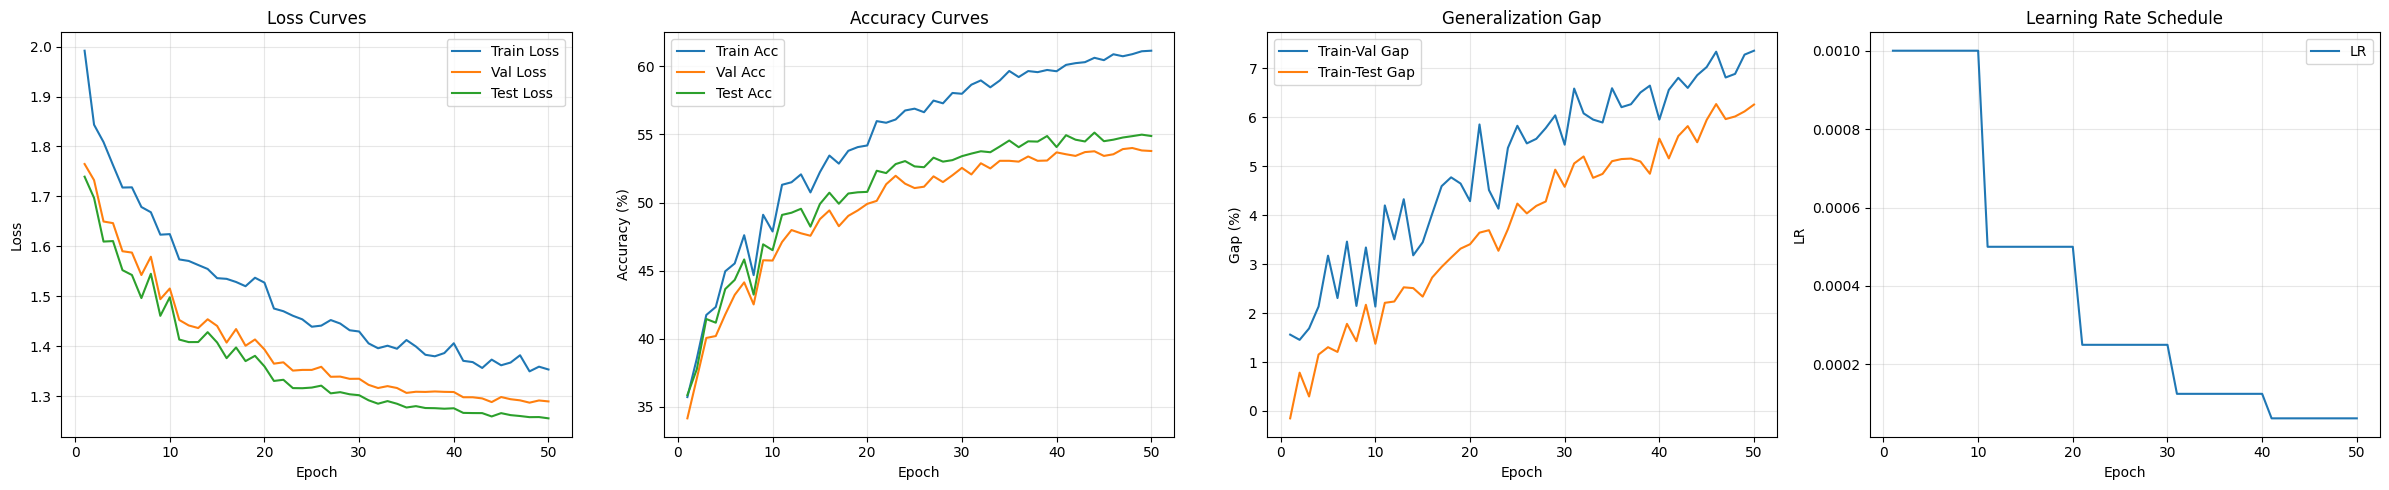

In [18]:
# =========================================================
# 14) Plot Final Best Curves
# =========================================================
history = final_result["history"]
epochs_range = range(1, len(history["train_losses"]) + 1)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

axes[0].plot(epochs_range, history["train_losses"], label="Train Loss")
axes[0].plot(epochs_range, history["val_losses"], label="Val Loss")
axes[0].plot(epochs_range, history["test_losses"], label="Test Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_accuracies"], label="Train Acc")
axes[1].plot(epochs_range, history["val_accuracies"], label="Val Acc")
axes[1].plot(epochs_range, history["test_accuracies"], label="Test Acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

train_val_gap = np.array(history["train_accuracies"]) - np.array(history["val_accuracies"])
train_test_gap = np.array(history["train_accuracies"]) - np.array(history["test_accuracies"])
axes[2].plot(epochs_range, train_val_gap, label="Train-Val Gap")
axes[2].plot(epochs_range, train_test_gap, label="Train-Test Gap")
axes[2].set_title("Generalization Gap")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Gap (%)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(epochs_range, history["lr_history"], label="LR")
axes[3].set_title("Learning Rate Schedule")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("LR")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# =========================================================
# 15) Final Summary Table
# =========================================================
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print("Fixed full-combo techniques:")
print(f"  - Dropout: {dropout_p}")
print(f"  - BatchNorm: ON")
print(f"  - L1 lambda: {l1_lambda}")
print(f"  - L2 weight decay: {l2_weight_decay}")
print(f"  - Data Augmentation: ON")
print(f"  - Adversarial Training: ON (ratio={adv_ratio}, epsilon={epsilon})")
print(f"  - Early Stopping: ON (patience={patience})")
print("\nBest optimization setup:")
print(f"  - Optimizer: {final_result['optimizer']}")
print(f"  - Learning Rate: {final_result['lr']}")
print(f"  - Scheduler: {final_result['scheduler']}")
print("\nFinal results:")
print(f"  - Train Accuracy: {final_result['train_acc']:.2f}%")
print(f"  - Validation Accuracy: {final_result['val_acc']:.2f}%")
print(f"  - Test Accuracy: {final_result['test_acc']:.2f}%")
print(f"  - Adversarial Accuracy: {final_result['adv_test_acc']:.2f}%")
print(f"  - Train-Val Gap: {final_result['train_val_gap']:.2f}%")
print(f"  - Train-Test Gap: {final_result['train_test_gap']:.2f}%")
print("=" * 80)


FINAL SUMMARY
Fixed full-combo techniques:
  - Dropout: 0.2
  - BatchNorm: ON
  - L1 lambda: 5e-07
  - L2 weight decay: 0.0001
  - Data Augmentation: ON
  - Adversarial Training: ON (ratio=0.15, epsilon=0.03)
  - Early Stopping: ON (patience=10)

Best optimization setup:
  - Optimizer: AdamW
  - Learning Rate: 0.001
  - Scheduler: StepLR

Final results:
  - Train Accuracy: 60.89%
  - Validation Accuracy: 54.00%
  - Test Accuracy: 54.87%
  - Adversarial Accuracy: 43.35%
  - Train-Val Gap: 6.89%
  - Train-Test Gap: 6.02%
